### Testing overexpression candidates from STABL for isoprenol production

In [1]:
import warnings
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from textwrap import wrap
from matplotlib.font_manager import FontProperties
import re
from scipy import stats
from matplotlib.lines import Line2D 

line_size=0.5
custom_params = {
    'axes.facecolor': 'white',
    'axes.edgecolor': 'black',
    'axes.grid': False,
    'axes.axisbelow': 'line',
    'axes.labelcolor': 'black',
    'figure.facecolor': 'white',
    "axes.spines.right": True, 
    "axes.spines.bottom": True,
    'xtick.direction': 'inout',
    'ytick.direction': 'in',
    'xtick.bottom': True,
    'xtick.minor.visible': False,
    'xtick.major.bottom':  True,
    'xtick.minor.bottom':  True,
    'xtick.major.pad':     7,     # distance to major tick label in points#
    'xtick.minor.pad':     3.4,     # distance to the minor tick label in points#
    'xtick.major.size':    10,
    'ytick.major.size':    4,
    'xtick.major.width':   line_size,
    'ytick.major.width':   line_size,
    'axes.linewidth': line_size,
    'xtick.minor.size':    2,
    'pdf.fonttype': 42}

sns.set_theme(style="ticks", rc=custom_params, font="Arial",font_scale=0.7)

enmax_palette = ["#648FFF", "#FE6100", "#785EF0", "#DC267F", "#FFB000"]
sns.set_palette(palette=enmax_palette)
warnings.filterwarnings("ignore")

#### Fig. S12a

In [2]:
output_dir = "Figure_Export"

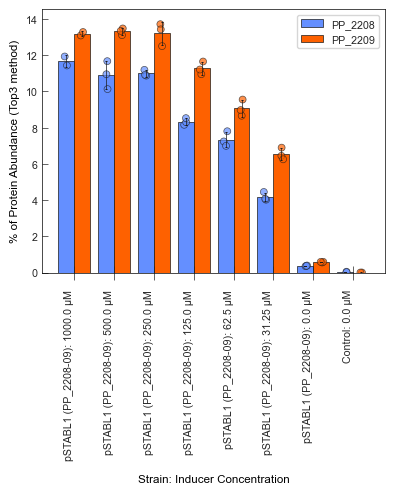

Plot saved to Figure_Export\Fig_S12a.pdf


In [3]:
filename = "pSTABL1_proteomics.csv"
df = pd.read_csv(f'Figure_Data/{filename}')

df["%_of protein_abundance_Top3-method"] = pd.to_numeric(df["%_of protein_abundance_Top3-method"], errors="coerce")
df["Strain_Conc"] = df["Strain"] + ": " + df["Inducer concentration"].astype(str) + " µM"

fig, ax = plt.subplots(figsize=(4, 5))

with sns.color_palette():
    sns.stripplot(
        data=df,
        x="Strain_Conc",
        y="%_of protein_abundance_Top3-method",
        hue='Protein.Description', dodge=True, alpha=0.7,
        linewidth=line_size, edgecolor="k", zorder=2, ax=ax,
        legend=False  # prevent stripplot from adding to legend
    )
    barplot = sns.barplot(
        data=df,
        x="Strain_Conc",
        y="%_of protein_abundance_Top3-method",
        hue='Protein.Description', errorbar="sd", zorder=0, capsize=0.1,
        linewidth=line_size, edgecolor="k", saturation=1,
        errwidth=line_size, errcolor="k",
        dodge=True, ax=ax
    )

# Get legend handles/labels from barplot only
handles, labels = barplot.get_legend_handles_labels()
barplot.legend_.set_title(None)

plt.ylabel("% of Protein Abundance (Top3 method)")
plt.xlabel("Strain: Inducer Concentration", labelpad=10)
plt.xticks(rotation=90, ha="right")
plt.tight_layout()
ax.margins(x=0.05)
output_pdf = os.path.join(output_dir, "Fig_S12a.pdf")
plt.savefig(output_pdf, dpi=400, bbox_inches='tight', format='pdf')
plt.show()

print(f"Plot saved to {output_pdf}")

#### Fig. S12b

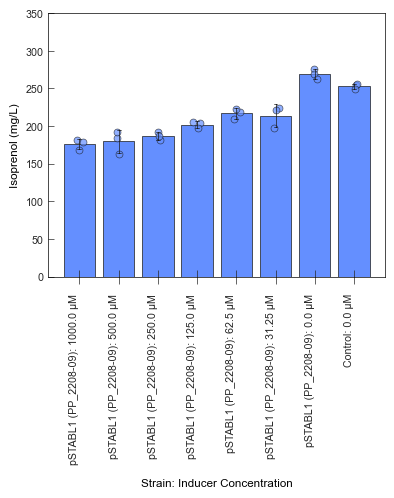

Plot saved to Figure_Export\Fig_S12b.pdf


In [4]:
filename = "pSTABL1_GCFID.csv"
df = pd.read_csv(f'Figure_Data/{filename}')

df["Strain_Conc"] = df["Strain"] + ": " + df["Inducer concentration"].astype(str) + " µM"

fig, ax = plt.subplots(figsize=(4, 5))

with sns.color_palette():
    sns.stripplot(
        data=df,
        x="Strain_Conc",
        y="Isoprenol",
        dodge=True, alpha=0.7, color="#648FFF",
        linewidth=line_size, edgecolor="k", zorder=2, ax=ax
    )
    sns.barplot(
        data=df,
        x="Strain_Conc",
        y="Isoprenol",
        errorbar="sd", zorder=0, capsize=0.1,
        linewidth=line_size, edgecolor="k", saturation=1,
        errwidth=line_size, errcolor="k",
        dodge=True, ax=ax,
        color="#648FFF"
    )

plt.ylabel("Isoprenol (mg/L)")
plt.xlabel("Strain: Inducer Concentration", labelpad=10)
plt.xticks(rotation=90, ha="right")
plt.tight_layout()
ax.set_ylim(0, 350)
ax.margins(x=0.05) 
output_pdf = os.path.join(output_dir, "Fig_S12b.pdf")
plt.savefig(output_pdf, dpi=400, bbox_inches='tight', format='pdf')
plt.show()

print(f"Plot saved to {output_pdf}")

#### Fig. S12c

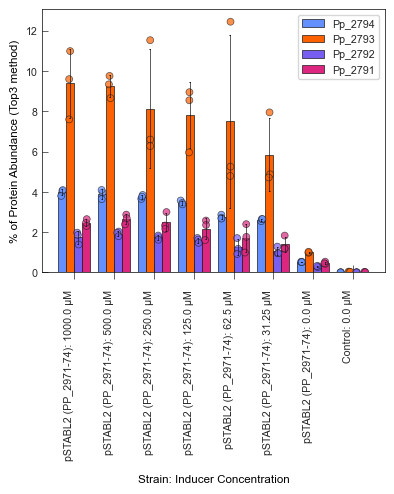

Plot saved to Figure_Export\Fig_S12c.pdf


In [5]:
filename = "pSTABL2_proteomics.csv"
df = pd.read_csv(f'Figure_Data/{filename}')

df["%_of protein_abundance_Top3-method"] = pd.to_numeric(df["%_of protein_abundance_Top3-method"], errors="coerce")
df["Strain_Conc"] = df["Strain"] + ": " + df["Inducer concentration"].astype(str) + " µM"

fig, ax = plt.subplots(figsize=(4, 5))

with sns.color_palette():
    sns.stripplot(
        data=df,
        x="Strain_Conc",
        y="%_of protein_abundance_Top3-method",
        hue='Protein', dodge=True, alpha=0.7,
        linewidth=line_size, edgecolor="k", zorder=2, ax=ax,
        legend=False  # prevent stripplot from adding to legend
    )
    barplot = sns.barplot(
        data=df,
        x="Strain_Conc",
        y="%_of protein_abundance_Top3-method",
        hue='Protein', errorbar="sd", zorder=0, capsize=0.1,
        linewidth=line_size, edgecolor="k", saturation=1,
        errwidth=line_size, errcolor="k",
        dodge=True, ax=ax
    )

# Get legend handles/labels from barplot only
handles, labels = barplot.get_legend_handles_labels()
barplot.legend_.set_title(None)

plt.ylabel("% of Protein Abundance (Top3 method)")
plt.xlabel("Strain: Inducer Concentration", labelpad=10)
plt.xticks(rotation=90, ha="right")
plt.tight_layout()
ax.margins(x=0.05)
output_pdf = os.path.join(output_dir, "Fig_S12c.pdf")
plt.savefig(output_pdf, dpi=400, bbox_inches='tight', format='pdf')
plt.show()

print(f"Plot saved to {output_pdf}")

#### Fig. S12d

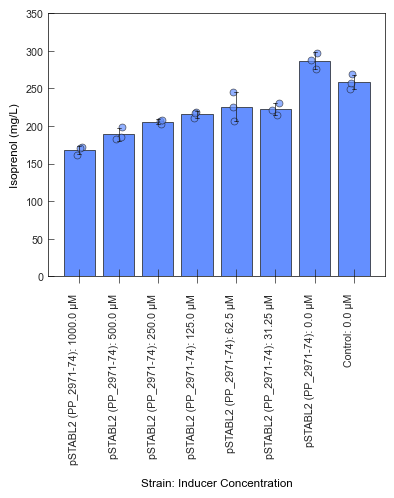

Plot saved to Figure_Export\Fig_S12d.pdf


In [6]:
filename = "pSTABL2_GCFID.csv"
df = pd.read_csv(f'Figure_Data/{filename}')

df["Strain_Conc"] = df["Strain"] + ": " + df["Inducer concentration"].astype(str) + " µM"

fig, ax = plt.subplots(figsize=(4, 5))

with sns.color_palette():
    sns.stripplot(
        data=df,
        x="Strain_Conc",
        y="Isoprenol",
        dodge=True, alpha=0.7, color="#648FFF",
        linewidth=line_size, edgecolor="k", zorder=2, ax=ax
    )
    sns.barplot(
        data=df,
        x="Strain_Conc",
        y="Isoprenol",
        errorbar="sd", zorder=0, capsize=0.1,
        linewidth=line_size, edgecolor="k", saturation=1,
        errwidth=line_size, errcolor="k",
        dodge=True, ax=ax,
        color="#648FFF"
    )

plt.ylabel("Isoprenol (mg/L)")
plt.xlabel("Strain: Inducer Concentration", labelpad=10)
plt.xticks(rotation=90, ha="right")
plt.tight_layout()
ax.set_ylim(0, 350)
ax.margins(x=0.05) 
output_pdf = os.path.join(output_dir, "Fig_S12d.pdf")
plt.savefig(output_pdf, dpi=400, bbox_inches='tight', format='pdf')
plt.show()

print(f"Plot saved to {output_pdf}")